# Project 1
## s224360

## Part1: A discrete-time model
### task 1.1

In [ ]:
import numpy as np

# P is pi,j from state i to state j
# death is the last row

# 0: state is surgery
# 1: local occurence only
# 2: distant matatasis 
# 3: local and distant occurence
# 4: death 

P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
              [0 ,     0.986, 0.005, 0.004, 0.005],
              [0,     0, 0.992, 0.003, 0.005],
              [0, 0,0 , 0.991, 0.009],
              [0,0,0,0,1]])
P



array([[0.9915, 0.005 , 0.0025, 0.    , 0.001 ],
       [0.    , 0.986 , 0.005 , 0.004 , 0.005 ],
       [0.    , 0.    , 0.992 , 0.003 , 0.005 ],
       [0.    , 0.    , 0.    , 0.991 , 0.009 ],
       [0.    , 0.    , 0.    , 0.    , 1.    ]])

In [23]:
def sample_conditional_next_state(i, P):
    possible_j = np.arange(i,5,1)
    probs = P[i,i:]
    return np.random.choice(possible_j, p=probs)

sample_conditional_next_state(1, P)

np.int64(1)

In [47]:
import math
np.random.seed(42)
def sample_conditional_next_state(i, P):
    possible_j = np.arange(i,5,1)
    probs = P[i,i:]
    return np.random.choice(possible_j, p=probs)


def gibbs_sampler(P, N_women, start=0):

    life_times = []

    local_occuring_cancer = 0
    state_at_120_all = []
    for w in range (N_women):

        current_state = start
        lifetime_w = 0
        local_occuring_cancer_w = 0
        state_at_120 = 4
        while current_state<4:
            
            current_state = sample_conditional_next_state(current_state, P)
            lifetime_w +=1
            if current_state==1 or current_state==3:
                local_occuring_cancer_w = 1
            
            if lifetime_w==120:
                state_at_120 = current_state
        
        state_at_120_all.append(int(state_at_120))
        local_occuring_cancer += local_occuring_cancer_w
        life_times.append(lifetime_w)
    
    life_times = np.array(life_times)

    return life_times, local_occuring_cancer, state_at_120_all


life_times,local_occuring_cancer,state_at_120_all = gibbs_sampler(P, 1000, start=0)



Amount of women with reoccuring cancer is 71.2 %


Text(0.5, 0, 'Months')

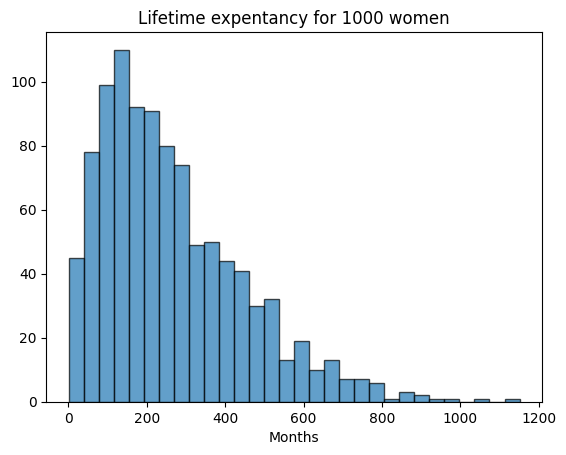

In [30]:
import matplotlib.pyplot as plt
print(f"Amount of women with reoccuring cancer is {np.round(local_occuring_cancer/1000*100,2)} %")
plt.hist(life_times, bins=30, edgecolor= 'black', alpha=0.7)
plt.title('Lifetime expentancy for 1000 women')
plt.xlabel('Months')

### Task 1.2

In [ ]:
# pt is the probability distribution over the states at time t
# pt = p0(P^t)

p0 = P[0,:]
p120 = p0 @  (np.linalg.matrix_power(P,120))
print(f"Theoretical prob. of state at t=120 {p120}")

Theoretical prob of state at t=120 [0.35597454 0.15852579 0.16645055 0.06826591 0.25078322]


In [58]:
# our simulations:
values, counts = np.unique_counts(state_at_120_all)
simulated_120_prob = counts /len(state_at_120_all)
print(f"Simulated prob. of state at t=120 {simulated_120_prob}")

Simulated prob. of state at t=120 [0.364 0.165 0.167 0.069 0.235]


In [68]:
from scipy.stats import chisquare
stat, p_value = chisquare(f_obs=counts, f_exp = p120*1000)
print(f" Chi-statistical statistic: {np.round(stat,4)}")
print(f'p-value: {np.round(p_value,4)}')

 Chi-statistical statistic: 1.4484
p-value: 0.8357


### task 1.3

In [86]:
pi_ = P[0,:4]
Ps = P[:4,:4]
ps = P[1:,4]

def probability_mass_function(t):
    return pi_@(np.linalg.matrix_power(Ps,t))@ps

def probability_mean():
    inv_PsI = np.linalg.inv(np.eye(4)-Ps)
    return pi_@(inv_PsI)@np.ones((4))



probability_mean(), probability_mass_function(5)

(np.float64(261.3716153127931), np.float64(0.005422653181122353))

In [83]:
ps

array([0.001, 0.005, 0.005, 0.009, 1.   ])

In [82]:
pi_

array([0.9915, 0.005 , 0.0025, 0.    ])

In [81]:
np.linalg.matrix_power(Ps,5)

array([[9.58216385e-01, 2.38942121e-02, 1.23350318e-02, 2.67605815e-04],
       [0.00000000e+00, 9.31932752e-01, 2.39184574e-02, 1.92413916e-02],
       [0.00000000e+00, 0.00000000e+00, 9.60634900e-01, 1.44964731e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.55802743e-01]])

In [77]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])